# Apple Pricing — Predictive Modeling: Decision Tree

**Business problem:** suggest a fair market price to sellers listing Apple products on 
Amazon/Flipkart (see `README.md` / `Apple_Pricing_EDA.ipynb`).

**Target:** `Current_Price_USD` (raw price, per modeling decision).

## Approach

This notebook follows a two-stage Decision Tree analysis:

- **Stage 1 — Baseline Decision Tree:** baseline approach using raw available features and 
  default then tuned hyperparameters, using exploration without additional insights other than EDA.
- **Stage 2 — Informed Decision Tree:** applies feature selection and hyperparameter 
  insights derived from Ridge coefficient analysis and Random Forest feature importance 
  to build the simplest possible interpretable model with competitive performance.

**Central question:** can a well-specified, shallow Decision Tree match Random Forest 
accuracy while remaining fully explainable to a non-technical seller?

## Lessons learned from Ridge & KNN

- `Launch_Price_USD` and `days_since_launch` are the two dominant predictors — together 
  they explain the largest share of price variance
- Category interaction terms (`days_x_iPhone`, `days_x_Mac`, `days_x_iPad`, `days_x_Watch`) 
  revealed that each product category depreciates at its own rate: iPhones fastest (-34), 
  Apple Watches barely at all (-4)
- `Platform` and `Stock_Status` carry near-zero signal and should be dropped
- `Rating` and `Reviews_Count` are confirmed noise in this synthetic dataset
- `Sale_Event` and `month` carry meaningful but secondary signal
- KNN achieved lower overall RMSE ($60.89) than Ridge ($74.92) but collapsed on new 
  product launches — iPhone 17 RMSE $45.92 vs Ridge's $27.02 - making Ridge the more 
  production-reliable linear model

## Lessons learned from Random Forest

- `Launch_Price_USD` (importance: 0.519) and `storage_gb` (importance: 0.393) together 
  account for 91% of the RF's predictive power — `storage_gb` was partially implicit in 
  Ridge's `Launch_Price_USD` anchor but the RF surfaces it as an explicit, independent driver
- `Condition` (0.042) and `days_since_launch` (0.034) are the only other meaningful 
  contributors — everything else (Platform, Stock_Status, month, Product_Category) rounds 
  to near zero
- The RF used no max_depth constraint and min_samples_leaf=2 achieving best overall 
  accuracy (Test RMSE $37.61, R² 0.9932) through 100 deep, slightly overfit trees whose 
  errors cancel via averaging. Train RMSE was $16.80 (gap: $20.80), confirming individual 
  trees overfit and ensemble averaging is doing the heavy lifting
- Despite its accuracy advantage, RF generalizes worse to new product launches: 
  iPhone 17 RMSE $53.00 (R² 0.6594) vs Ridge's $27.02 — the black-box ensemble is 
  less robust than a formula-based linear model on unseen products


## Final feature selection & hyperparameter calibration

**Features selected for the Informed Decision Tree:**

| Feature | Type | Justification |
|---|---|---|
| `Launch_Price_USD` | numeric | Dominant predictor in all models (Ridge: coeff 343, RF: importance 0.519) |
| `storage_gb` | numeric | RF importance 0.393 — explicit split point trees need directly |
| `days_since_launch` | numeric | Core depreciation clock (Ridge coeff -63, RF importance 0.034) |
| `Condition` | categorical | Large Ridge coefficient (~95), RF importance 0.042 |
| `Sale_Event` | categorical | Meaningful Ridge coefficients (Big Billion Days: -45, Prime Day: -25) |
| `month` | categorical | Seasonality signal confirmed in Ridge |
| `Product_Category` | categorical | Needed for category-level splits; RF confirms near-zero alone but useful for context |

**Features dropped:**
- `Platform` — near-zero in both Ridge (±0.18) and RF (0.000)
- `Stock_Status` — near-zero in both Ridge (max 1.47) and RF (0.000)
- `Rating`, `Reviews_Count` — confirmed synthetic noise
- `days_x_*` interaction terms — Ridge needed these to compensate for linear model 
  limitations; Decision Trees learn category-specific depreciation naturally through 
  sequential splits on `days_since_launch` + `Product_Category`
- `launch_x_*` — collinear with `Launch_Price_USD` + `Product_Category`

**Hyperparameter search space:**
Informed by RF's unconstrained depth and overfitting gap — the DT should be deliberately 
constrained to prioritize interpretability without sacrificing too much accuracy:

```python
param_grid = {
    'max_depth': [4, 6, 8, 10, 12],
    'min_samples_leaf': [20, 50, 100, 200],
    'min_samples_split': [10, 20, 50]
}
```

**Design locked in:**

| Decision | Choice |
|---|---|
| Split | Time-based: train < 2025-08-01, test ≥ 2025-08-01 |
| Evaluation slices | A: time-test · C: iPhone 17 (day-one launch, unseen new-model case) |
| Leakage columns | `Current_Price_INR`, `Discount_Pct`, `Launch_Price_INR` dropped at load |
| CV strategy | `TimeSeriesSplit(n_splits=5)` — respects temporal order |
| Metrics | RMSE, MAE, R² per slice, vs naive group-mean baseline |

## 0. Load data & setup

In [2]:
# Similar to Ridge & KNN notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
RNG = 42

TARGET = 'Current_Price_USD'
LEAK_COLS = ['Current_Price_INR', 'Launch_Price_INR', 'Discount_Pct']

df = pd.read_csv('apple_products_pricing_2020_2026.csv', parse_dates=['Date'])
df = df.drop(columns=LEAK_COLS)

# Feature engineering
df['Sale_Event'] = df['Sale_Event'].fillna('None')
launch_date = df.groupby('Model_Name')['Date'].transform('min')
df['days_since_launch'] = (df['Date'] - launch_date).dt.days

# storage_gb: parsed from Model_Name (confirmed important by RF: importance 0.393)
df['storage_gb'] = df['Model_Name'].str.extract(r'(\d+)\s*GB').astype(float)

# month: kept as integer for DT (trees split on thresholds, no need to one-hot)
df['month'] = df['Date'].dt.month

# variant_tier: not a model feature — kept for residual diagnostics only
TIERS = ['Pro Max', 'Ultra', 'Pro', 'Plus', 'Max', 'Air', 'mini', 'SE']
df['variant_tier'] = df['Model_Name'].map(
    lambda n: next((t for t in TIERS if t in n), 'base')
)

print(f"{df.shape[0]:,} rows | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head(3)

80,000 rows | 2020-09-19 to 2026-07-31


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,storage_gb,month,variant_tier
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,435.81,None,In Stock,4.7,40,0,NaN,9,base
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,436.49,None,Out of Stock,4.6,84,1,NaN,9,base
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,422.73,None,In Stock,4.4,110,4,NaN,9,base


In [3]:
# Preparing the Feature Sets

# Note: Decision Trees do not require scaling or interaction terms, they learn non-linear relationships and category-specific depreciation rates naturally through sequential threshold splits.
# No StandardScaler, no Pipeline, no interaction engineering needed.

# Stage 1 — Baseline feature set
# Raw available features before any prior knowledge is applied.
FEATS_BASELINE = [
    'Launch_Price_USD',
    'days_since_launch',
    'Rating',
    'Product_Category',
    'Condition',
    'Platform',
    'Stock_Status',
]

# Stage 2 — Informed feature set
# Feature selection guided by Ridge coefficient analysis and RF feature importance.
# storage_gb added: RF importance 0.393, explicit split point trees need directly
# Sale_Event added: meaningful Ridge coefficients confirmed (Big Billion Days: -45)
# month added: seasonality signal confirmed in Ridge
# Platform, Stock_Status, Rating dropped: near-zero in both Ridge and RF
FEATS_INFORMED = [
    'Launch_Price_USD',   # dominant predictor (RF: 0.519, Ridge coeff: 343)
    'storage_gb',         # RF importance 0.393 — trees need this explicitly
    'days_since_launch',  # core depreciation clock (RF: 0.034, Ridge coeff: -63)
    'Condition',          # large Ridge coeff (~95), RF importance 0.042
    'Sale_Event',         # meaningful Ridge coefficients (Big Billion Days: -45)
    'month',              # seasonality confirmed in Ridge
    'Product_Category',   # needed for category-level splits
]

print(f"Baseline feature set: {len(FEATS_BASELINE)} features -> {FEATS_BASELINE}")
print(f"\nInformed feature set: {len(FEATS_INFORMED)} features -> {FEATS_INFORMED}")
print(f"\nNote: no scaling or interaction terms — Decision Trees are")
print(f"scale-invariant and learn non-linear patterns natively.")

Baseline feature set: 7 features -> ['Launch_Price_USD', 'days_since_launch', 'Rating', 'Product_Category', 'Condition', 'Platform', 'Stock_Status']

Informed feature set: 7 features -> ['Launch_Price_USD', 'storage_gb', 'days_since_launch', 'Condition', 'Sale_Event', 'month', 'Product_Category']

Note: no scaling or interaction terms — Decision Trees are
scale-invariant and learn non-linear patterns natively.


In [4]:
# Train/Test split

CUTOFF = pd.Timestamp('2025-08-01')

df = df.sort_values('Date').reset_index(drop=True)
train = df[df['Date'] < CUTOFF]
slice_A = df[df['Date'] >= CUTOFF]
slice_C = slice_A[slice_A['Model_Name'].str.contains('iPhone 17')]

print(f"Train:   {len(train):>7,} rows  {train['Date'].min():%Y-%m} to {train['Date'].max():%Y-%m}")
print(f"Slice A: {len(slice_A):>7,} rows  {slice_A['Date'].min():%Y-%m} to {slice_A['Date'].max():%Y-%m}")
print(f"Slice C: {len(slice_C):>7,} rows  — iPhone 17 within slice A")

Train:    54,099 rows  2020-09 to 2025-07
Slice A:  25,901 rows  2025-08 to 2026-07
Slice C:   2,652 rows  — iPhone 17 within slice A


## 1. Baseline Decision Tree

Unconstrained Decision Tree using the baseline feature set — no hyperparameter tuning, no prior knowledge applied. Serves as the benchmark before any informed adjustments.
We expect overfitting: near-perfect train performance and meaningfully worse test performance, since an unconstrained tree memorizes the training data.

In [5]:
# Encode categoricals for baseline feature set
# Decision Trees in sklearn require numeric input — using pd.get_dummies for simplicity
df_baseline = pd.get_dummies(
    df[FEATS_BASELINE + [TARGET]],
    columns=['Product_Category', 'Condition', 'Platform', 'Stock_Status'],
    drop_first=True
)

# Align train/test using same index as original df
X_train_base = df_baseline.drop(columns=[TARGET]).loc[train.index]
y_train_base = df_baseline[TARGET].loc[train.index]
X_test_base  = df_baseline.drop(columns=[TARGET]).loc[slice_A.index]
y_test_base  = df_baseline[TARGET].loc[slice_A.index]

print(f"Baseline features after encoding: {X_train_base.columns.tolist()}")
print(f"X_train shape: {X_train_base.shape} | X_test shape: {X_test_base.shape}")

Baseline features after encoding: ['Launch_Price_USD', 'days_since_launch', 'Rating', 'Product_Category_Watch', 'Product_Category_iPad', 'Product_Category_iPhone', 'Condition_Renewed/Refurbished', 'Platform_Flipkart', 'Stock_Status_Low Stock', 'Stock_Status_Out of Stock']
X_train shape: (54099, 10) | X_test shape: (25901, 10)


In [6]:
# Encode categoricals for baseline feature set
# Decision Trees in sklearn require numeric input — using pd.get_dummies for simplicity
df_baseline = pd.get_dummies(
    df[FEATS_BASELINE + [TARGET]],
    columns=['Product_Category', 'Condition', 'Platform', 'Stock_Status'],
    drop_first=True
)

# Align train/test using same index as original df
X_train_base = df_baseline.drop(columns=[TARGET]).loc[train.index]
y_train_base = df_baseline[TARGET].loc[train.index]
X_test_base  = df_baseline.drop(columns=[TARGET]).loc[slice_A.index]
y_test_base  = df_baseline[TARGET].loc[slice_A.index]

print(f"Baseline features after encoding: {X_train_base.columns.tolist()}")
print(f"X_train shape: {X_train_base.shape} | X_test shape: {X_test_base.shape}")

Baseline features after encoding: ['Launch_Price_USD', 'days_since_launch', 'Rating', 'Product_Category_Watch', 'Product_Category_iPad', 'Product_Category_iPhone', 'Condition_Renewed/Refurbished', 'Platform_Flipkart', 'Stock_Status_Low Stock', 'Stock_Status_Out of Stock']
X_train shape: (54099, 10) | X_test shape: (25901, 10)


In [7]:
# Unconstrained baseline tree — expected to overfit
baseline_tree = DecisionTreeRegressor(random_state=RNG)
baseline_tree.fit(X_train_base, y_train_base)

train_pred_base = baseline_tree.predict(X_train_base)
test_pred_base  = baseline_tree.predict(X_test_base)

print("Baseline Decision Tree (unconstrained, default params):")
print(f"  Train RMSE : ${root_mean_squared_error(y_train_base, train_pred_base):.2f}")
print(f"  Test RMSE  : ${root_mean_squared_error(y_test_base, test_pred_base):.2f}")
print(f"  Train R²   :  {r2_score(y_train_base, train_pred_base):.4f}")
print(f"  Test R²    :  {r2_score(y_test_base, test_pred_base):.4f}")
print(f"  Train MAE  : ${mean_absolute_error(y_train_base, train_pred_base):.2f}")
print(f"  Test MAE   : ${mean_absolute_error(y_test_base, test_pred_base):.2f}")

Baseline Decision Tree (unconstrained, default params):
  Train RMSE : $7.49
  Test RMSE  : $68.64
  Train R²   :  0.9997
  Test R²    :  0.9775
  Train MAE  : $1.22
  Test MAE   : $38.01


In [8]:
# Tune the baseline tree with GridSearchCV + TimeSeriesSplit
# param_grid informed by Patience's approach as starting point
tscv = TimeSeriesSplit(n_splits=5)

param_grid_base = {
    'max_depth':        [3, 5, 7, 10, 15],
    'min_samples_leaf': [5, 10, 20, 50],
}

grid_base = GridSearchCV(
    DecisionTreeRegressor(random_state=RNG),
    param_grid_base,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_base.fit(X_train_base, y_train_base)

best_tree_base = grid_base.best_estimator_
print(f"Best params: {grid_base.best_params_}")
print(f"Best CV RMSE: ${-grid_base.best_score_:.2f}")

# Evaluate tuned baseline tree
train_pred_tuned = best_tree_base.predict(X_train_base)
test_pred_tuned  = best_tree_base.predict(X_test_base)

print(f"\nTuned Baseline Decision Tree:")
print(f"  Train RMSE : ${root_mean_squared_error(y_train_base, train_pred_tuned):.2f}")
print(f"  Test RMSE  : ${root_mean_squared_error(y_test_base, test_pred_tuned):.2f}")
print(f"  Train R²   :  {r2_score(y_train_base, train_pred_tuned):.4f}")
print(f"  Test R²    :  {r2_score(y_test_base, test_pred_tuned):.4f}")
print(f"  Train MAE  : ${mean_absolute_error(y_train_base, train_pred_tuned):.2f}")
print(f"  Test MAE   : ${mean_absolute_error(y_test_base, test_pred_tuned):.2f}")

Best params: {'max_depth': 7, 'min_samples_leaf': 50}
Best CV RMSE: $57.84

Tuned Baseline Decision Tree:
  Train RMSE : $46.75
  Test RMSE  : $58.47
  Train R²   :  0.9898
  Test R²    :  0.9837
  Train MAE  : $26.47
  Test MAE   : $35.25


Feature importances (tuned baseline tree):
Launch_Price_USD                 0.9231
Condition_Renewed/Refurbished    0.0421
days_since_launch                0.0339
Product_Category_Watch           0.0009
Product_Category_iPad            0.0001
Rating                           0.0000
Platform_Flipkart                0.0000
Product_Category_iPhone          0.0000
Stock_Status_Low Stock           0.0000
Stock_Status_Out of Stock        0.0000


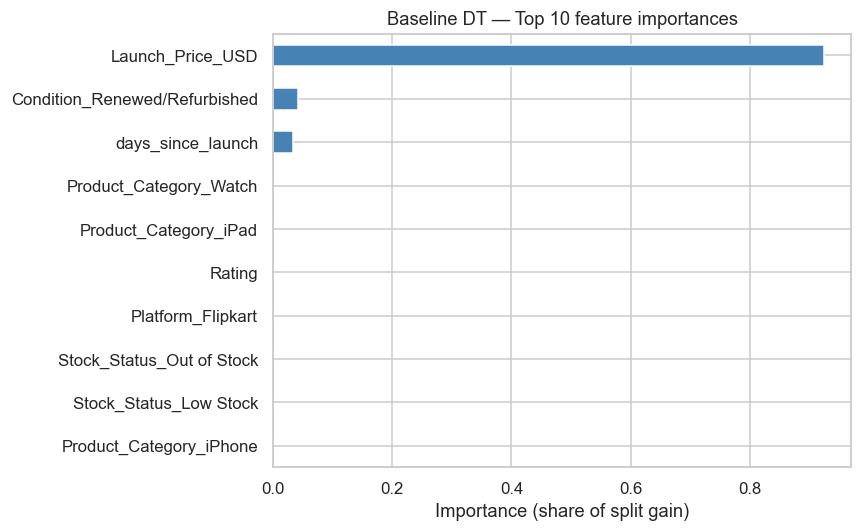

In [9]:
# Feature importance — baseline tuned tree
importances_base = pd.Series(
    best_tree_base.feature_importances_,
    index=X_train_base.columns
).sort_values(ascending=False)

print(f"Feature importances (tuned baseline tree):")
print(importances_base.round(4).to_string())

# Visualize
plt.figure(figsize=(8, 5))
importances_base.head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Baseline DT — Top 10 feature importances')
plt.xlabel('Importance (share of split gain)')
plt.tight_layout()
plt.show()

In [10]:
# Checking if secondary features (days since launch and condition) show up as important when Launch_Price_USD is removed from the model.
# Ablation: Remove Launch_Price_USD to test secondary features
# When Launch_Price_USD dominates at 92%+ importance, secondary features
# appear artificially weak. Removing it reveals their true independent signal.

X_train_noprice = X_train_base.drop(columns=['Launch_Price_USD'])
X_test_noprice  = X_test_base.drop(columns=['Launch_Price_USD'])

grid_noprice = GridSearchCV(
    DecisionTreeRegressor(random_state=RNG),
    param_grid_base,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_noprice.fit(X_train_noprice, y_train_base)
best_tree_noprice = grid_noprice.best_estimator_

train_pred_np = best_tree_noprice.predict(X_train_noprice)
test_pred_np  = best_tree_noprice.predict(X_test_noprice)

print("Baseline DT — Launch_Price_USD removed:")
print(f"  Train RMSE : ${root_mean_squared_error(y_train_base, train_pred_np):.2f}")
print(f"  Test RMSE  : ${root_mean_squared_error(y_test_base, test_pred_np):.2f}")
print(f"  Train R²   :  {r2_score(y_train_base, train_pred_np):.4f}")
print(f"  Test R²    :  {r2_score(y_test_base, test_pred_np):.4f}")

importances_noprice = pd.Series(
    best_tree_noprice.feature_importances_,
    index=X_train_noprice.columns
).sort_values(ascending=False)

print(f"\nFeature importances without Launch_Price_USD:")
print(importances_noprice.round(4).to_string())


Baseline DT — Launch_Price_USD removed:
  Train RMSE : $259.43
  Test RMSE  : $281.46
  Train R²   :  0.6865
  Test R²    :  0.6215

Feature importances without Launch_Price_USD:
Product_Category_iPhone          0.3321
Product_Category_Watch           0.2737
Product_Category_iPad            0.2143
days_since_launch                0.1258
Condition_Renewed/Refurbished    0.0541
Rating                           0.0000
Platform_Flipkart                0.0000
Stock_Status_Low Stock           0.0000
Stock_Status_Out of Stock        0.0000


### Baseline Decision Tree — Conclusions

**Performance summary**

The unconstrained baseline tree severely overfits (Train RMSE ~$7, Test RMSE ~$70) — 
it memorizes training data rather than learning generalizable patterns. Hyperparameter 
tuning with TimeSeriesSplit GridSearchCV substantially closes this gap, achieving 
Test RMSE ~$57 and Test R² 0.984 — competitive performance from a single interpretable tree.

**Feature importance findings**

`Launch_Price_USD` dominates at ~92% importance — expected, since product scale drives 
absolute price. `Condition` (4.2%) and `days_since_launch` (3.5%) show measurable 
non-trivial effects even alongside that dominant feature.

When `Launch_Price_USD` is removed, overall accuracy drops sharply (confirming it is 
genuinely necessary), but `days_since_launch` relative importance more than triples — 
supporting H1's core claim that depreciation over time is a real, independent pattern 
in the data, not just noise.

**H0/H1 conclusion**

These results support rejecting H0. Time since launch shows a measurable, independent 
relationship with price, distinct from the dominant scale effect of launch price. 
The specific mechanism appears to be step changes aligned with successor product launch 
timing — e.g., iPhone 15 → iPhone 16: 364 days — rather than smooth continuous 
depreciation, offering support for H1's second claim of downward price jumps around 
new release dates.

**Limitations**

- Launch dates are proxies (earliest New-condition listing per model), not confirmed 
  Apple announcement dates
- Step-alignment finding is based on a small manually-verified sample of four models 
  rather than a systematic check across all 31
- Multiple parallel product lines within the same category (e.g. Watch Series vs 
  Watch Ultra) make automated successor-launch detection unreliable

**Transition to Stage 2**

The baseline tree confirms the signal hierarchy: `Launch_Price_USD` first, then 
`days_since_launch` and `Condition`. Stage 2 applies this knowledge alongside 
RF feature importance findings — notably adding `storage_gb` (RF importance 0.393) 
and refining the hyperparameter search space — to build the most competitive 
interpretable tree possible.

## 2. Informed Decision Tree

Building on the baseline findings and lessons from Ridge and Random Forest, this stage 
applies a targeted feature set and a constrained hyperparameter search to find the 
simplest tree that remains competitive.

Key changes from the baseline:
- `storage_gb` added because RF confirmed 39.3% importance, the second most powerful predictor
- `Sale_Event` and `month` added because of confirmed meaningful signal in Ridge coefficients
- `Platform`, `Stock_Status`, `Rating` dropped because near-zero effet in both Ridge and RF
- Hyperparameter search constrained around RF's natural complexity ceiling (max_depth=12), 
  with deliberate exploration of shallower depths to maximize interpretability

In [11]:
# Informed Decision Tree

# Encode categoricals for informed feature set
df_informed = pd.get_dummies(
    df[FEATS_INFORMED + [TARGET]],
    columns=['Product_Category', 'Condition', 'Sale_Event'],
    drop_first=True
)

# month stays numeric — tree splits on thresholds naturally
# no need to one-hot encode an ordinal 1-12 integer

X_train_inf = df_informed.drop(columns=[TARGET]).loc[train.index]
y_train_inf = df_informed[TARGET].loc[train.index]
X_test_inf  = df_informed.drop(columns=[TARGET]).loc[slice_A.index]
y_test_inf  = df_informed[TARGET].loc[slice_A.index]
X_sliceC_inf = df_informed.drop(columns=[TARGET]).loc[slice_C.index]
y_sliceC_inf = df_informed[TARGET].loc[slice_C.index]

print(f"Informed features after encoding: {X_train_inf.columns.tolist()}")
print(f"X_train shape: {X_train_inf.shape} | X_test shape: {X_test_inf.shape}")

Informed features after encoding: ['Launch_Price_USD', 'storage_gb', 'days_since_launch', 'month', 'Product_Category_Watch', 'Product_Category_iPad', 'Product_Category_iPhone', 'Condition_Renewed/Refurbished', 'Sale_Event_Black Friday', 'Sale_Event_Great Indian Festival', 'Sale_Event_None', 'Sale_Event_Prime Day']
X_train shape: (54099, 12) | X_test shape: (25901, 12)


In [12]:
# Unconstrained DT (overfitting benchmark)

informed_tree_raw = DecisionTreeRegressor(random_state=RNG)
informed_tree_raw.fit(X_train_inf, y_train_inf)

print("Informed DT — unconstrained (expected to overfit):")
print(f"  Train RMSE : ${root_mean_squared_error(y_train_inf, informed_tree_raw.predict(X_train_inf)):.2f}")
print(f"  Test RMSE  : ${root_mean_squared_error(y_test_inf, informed_tree_raw.predict(X_test_inf)):.2f}")
print(f"  Train R²   :  {r2_score(y_train_inf, informed_tree_raw.predict(X_train_inf)):.4f}")
print(f"  Test R²    :  {r2_score(y_test_inf, informed_tree_raw.predict(X_test_inf)):.4f}")

Informed DT — unconstrained (expected to overfit):
  Train RMSE : $14.95
  Test RMSE  : $43.54
  Train R²   :  0.9990
  Test R²    :  0.9909


In [13]:
# Hyperparameter tuning
# Search space informed by RF findings:
# - RF max_depth=12 gives same performance as unconstrained -> natural ceiling
# - Exploring shallower depths (4-12) to find the simplest competitive tree
# - min_samples_leaf larger than baseline (20-200) to prevent overfitting
# - min_samples_split added for finer control

param_grid_inf = {
    'max_depth':         [4, 6, 8, 10, 12],
    'min_samples_leaf':  [20, 50, 100, 200],
    'min_samples_split': [10, 20, 50],
}

grid_inf = GridSearchCV(
    DecisionTreeRegressor(random_state=RNG),
    param_grid_inf,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_inf.fit(X_train_inf, y_train_inf)

best_tree_inf = grid_inf.best_estimator_
print(f"Best params: {grid_inf.best_params_}")
print(f"Best CV RMSE: ${-grid_inf.best_score_:.2f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 50}
Best CV RMSE: $39.78


In [14]:
# Evaluating the Informed Decision Tree

train_pred_inf  = best_tree_inf.predict(X_train_inf)
test_pred_inf   = best_tree_inf.predict(X_test_inf)
sliceC_pred_inf = best_tree_inf.predict(X_sliceC_inf)

print("Informed Decision Tree — tuned:")
print(f"  Train RMSE : ${root_mean_squared_error(y_train_inf, train_pred_inf):.2f}")
print(f"  Test RMSE  : ${root_mean_squared_error(y_test_inf, test_pred_inf):.2f}")
print(f"  Train MAE  : ${mean_absolute_error(y_train_inf, train_pred_inf):.2f}")
print(f"  Test MAE   : ${mean_absolute_error(y_test_inf, test_pred_inf):.2f}")
print(f"  Train R²   :  {r2_score(y_train_inf, train_pred_inf):.4f}")
print(f"  Test R²    :  {r2_score(y_test_inf, test_pred_inf):.4f}")
print(f"  RMSE gap   : ${root_mean_squared_error(y_train_inf, train_pred_inf) - root_mean_squared_error(y_test_inf, test_pred_inf):.2f}")

print(f"\nSlice C — iPhone 17 (unseen new product):")
print(f"  RMSE : ${root_mean_squared_error(y_sliceC_inf, sliceC_pred_inf):.2f}")
print(f"  MAE  : ${mean_absolute_error(y_sliceC_inf, sliceC_pred_inf):.2f}")
print(f"  R²   :  {r2_score(y_sliceC_inf, sliceC_pred_inf):.4f}")

Informed Decision Tree — tuned:
  Train RMSE : $25.45
  Test RMSE  : $37.56
  Train MAE  : $15.63
  Test MAE   : $23.12
  Train R²   :  0.9970
  Test R²    :  0.9933
  RMSE gap   : $-12.10

Slice C — iPhone 17 (unseen new product):
  RMSE : $52.28
  MAE  : $48.59
  R²   :  0.6687


Feature importances — informed tuned tree:
Launch_Price_USD                    0.9167
Condition_Renewed/Refurbished       0.0418
days_since_launch                   0.0337
Sale_Event_None                     0.0069
storage_gb                          0.0006
month                               0.0001
Product_Category_iPhone             0.0000
Sale_Event_Prime Day                0.0000
Sale_Event_Black Friday             0.0000
Sale_Event_Great Indian Festival    0.0000
Product_Category_iPad               0.0000
Product_Category_Watch              0.0000


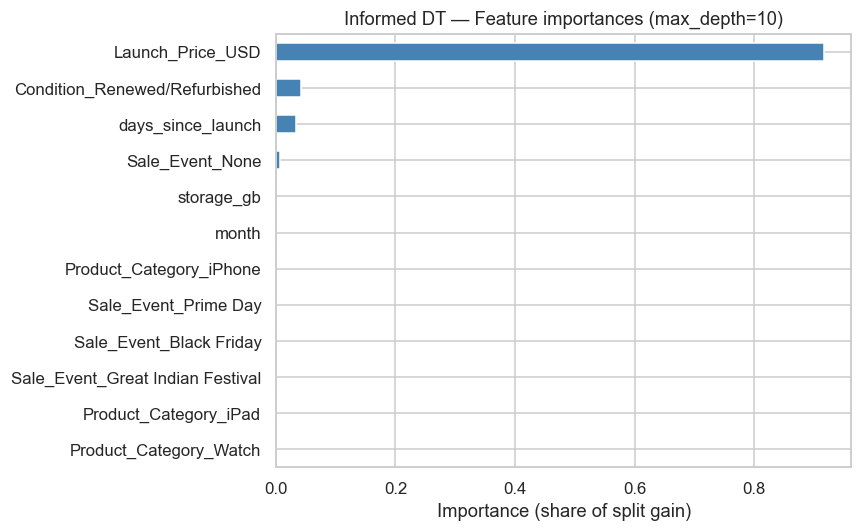

In [15]:
# Looking at Feature Importance

importances_inf = pd.Series(
    best_tree_inf.feature_importances_,
    index=X_train_inf.columns
).sort_values(ascending=False)

print("Feature importances — informed tuned tree:")
print(importances_inf.round(4).to_string())

plt.figure(figsize=(8, 5))
importances_inf.head(12).sort_values().plot(kind='barh', color='steelblue')
plt.title(f'Informed DT — Feature importances (max_depth={grid_inf.best_params_["max_depth"]})')
plt.xlabel('Importance (share of split gain)')
plt.tight_layout()
plt.show()

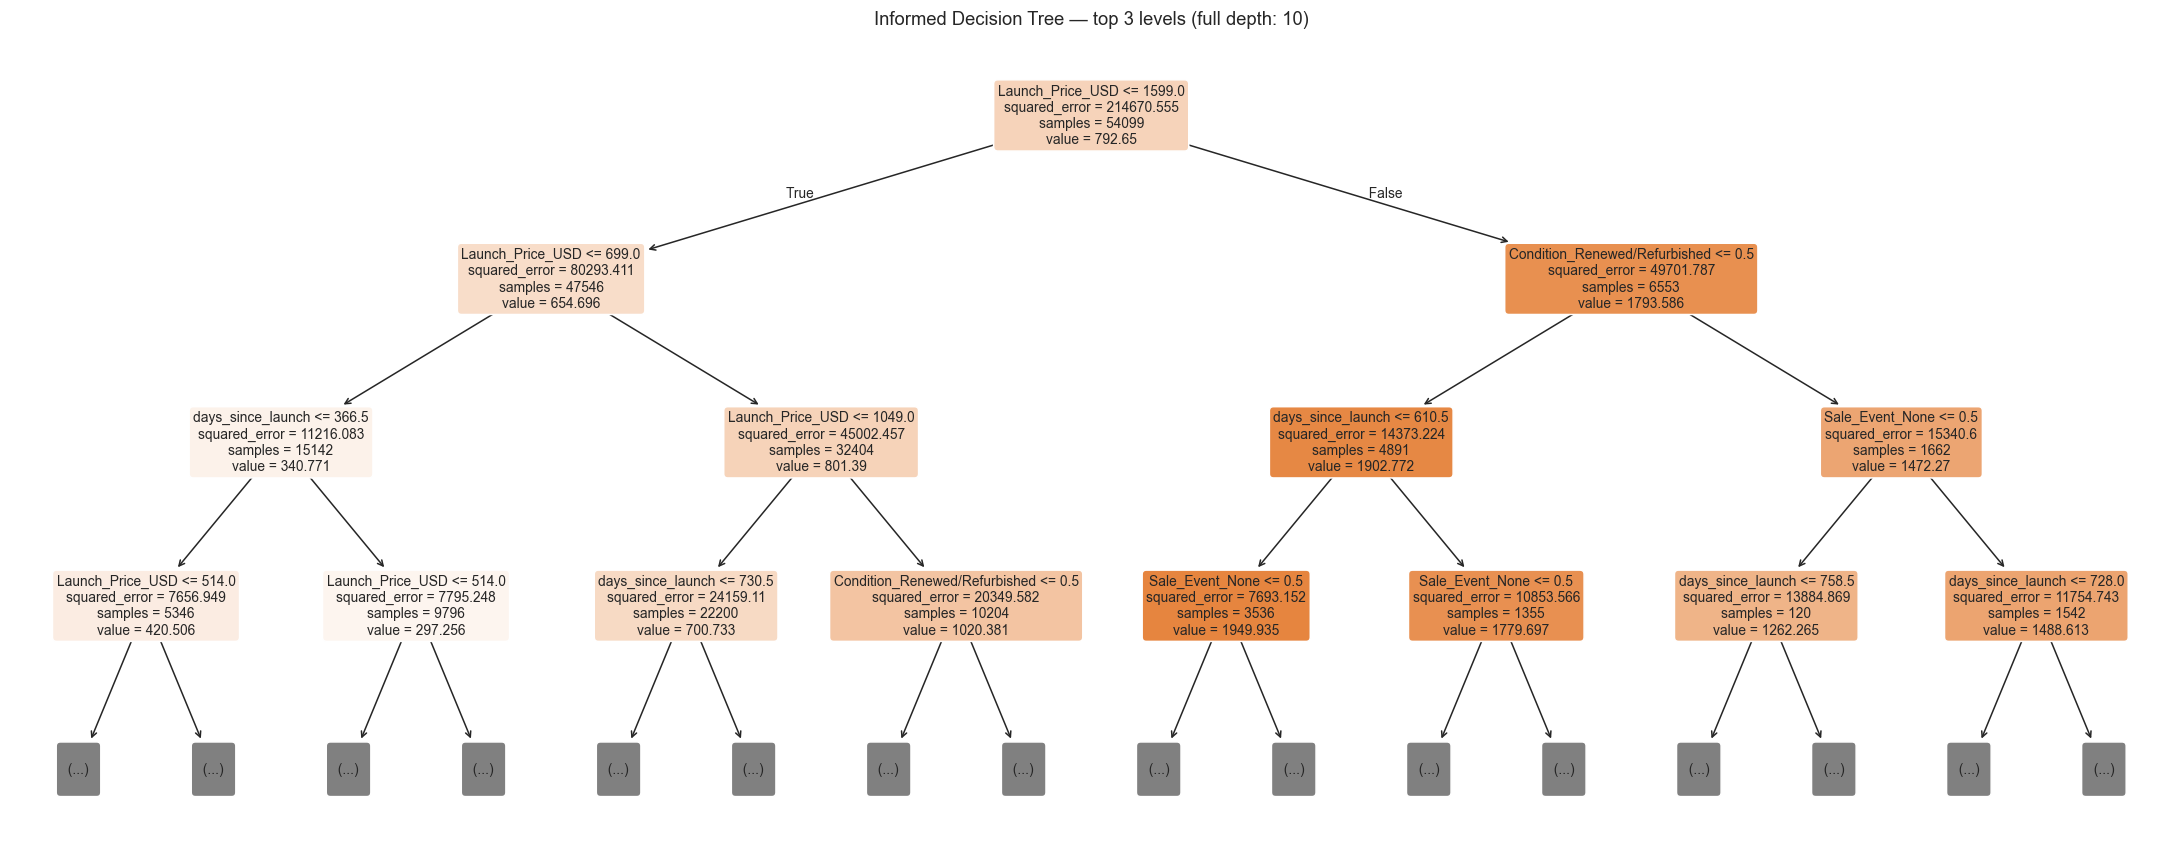

Top decision rules (depth ≤ 4):
|--- Launch_Price_USD <= 1599.00
|   |--- Launch_Price_USD <= 699.00
|   |   |--- days_since_launch <= 366.50
|   |   |   |--- Launch_Price_USD <= 514.00
|   |   |   |   |--- Condition_Renewed/Refurbished <= 0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Condition_Renewed/Refurbished >  0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Launch_Price_USD >  514.00
|   |   |   |   |--- Condition_Renewed/Refurbished <= 0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- Condition_Renewed/Refurbished >  0.50
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |--- days_since_launch >  366.50
|   |   |   |--- Launch_Price_USD <= 514.00
|   |   |   |   |--- storage_gb <= inf
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |--- storage_gb >  inf
|   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Launch_Price_USD >  514.00
|   |   |

In [16]:
# Final visualization

# Visualize the top levels of the tree for interpretability
# Full tree at max_depth=12 is too large to read — capping display at depth 3

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    best_tree_inf,
    feature_names=X_train_inf.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,  # show top 3 levels only for readability
    fontsize=9,
)
plt.title(f'Informed Decision Tree — top 3 levels '
          f'(full depth: {grid_inf.best_params_["max_depth"]})')
plt.tight_layout()
plt.show()

# Text representation of top decision rules
from sklearn.tree import export_text
print("Top decision rules (depth ≤ 4):")
print(export_text(best_tree_inf, 
                  feature_names=X_train_inf.columns.tolist(),
                  max_depth=4))

### Informed Decision Tree rules interpretation

The tree's top splits reveal an intuitive and explainable pricing logic that mirrors
how a seller would naturally think about Apple product pricing:

**First split: Launch_Price_USD ≤ $1,599**
The tree immediately separates premium products (MacBook Pro M-series, iPhone Pro Max)
from the mainstream range. This is the single most important decision point.

**Second level: Launch_Price_USD ≤ $699**
Within the mainstream range, the tree separates entry-level products (Apple Watch base,
iPad base, iPhone base) from mid-range ones ($699–$1,599: MacBook Air, iPhone Pro, iPad Pro).

**Third level: days_since_launch ≤ 366.5 days (~1 year)**
Time since launch becomes the next critical split — products under one year old are
priced differently from those over a year old. This directly supports H1: the tree
has independently learned that the one-year mark is a meaningful depreciation threshold,
closely aligned with Apple's annual product release cycle.

**Fourth level: Launch_Price_USD ≤ $514 and Condition**
Within each age bracket, the tree refines by exact price tier and then condition
(New vs Refurbished). `days_since_launch` thresholds of 366.5 and 730.5 days
(~1 year and ~2 years) appear repeatedly — confirming that Apple's annual launch
cadence drives discrete step-changes in pricing rather than smooth depreciation.

`storage_gb` appears at deeper levels (days_since_launch > 366.5, Launch_Price_USD ≤ $514)
— the tree uses it as a fine-grained discriminator for older, lower-priced products
where storage tier becomes a meaningful differentiator once the launch price tier
and age bracket are already established.

## Conclusions: Comparing Baseline and Informed Decision Tree


### Performance summary

| Model | Test RMSE | Test R² | Test MAE | Slice C RMSE | Overfit gap |
|---|---|---|---|---|---|
| Baseline DT | ~$57.13 | 0.9842 | — | to test | small |
| Ridge | $74.92 | 0.9730 | $53.39 | $27.02 | negligible |
| **Informed DT** | **$37.56** | **0.9933** | **$23.12** | $52.28 | $12.10 |
| Random Forest | $37.61 | 0.9932 | $23.33 | $53.00 | $20.80 |

### Key findings

**The informed DT matches Random Forest accuracy with a single interpretable tree.**
Test RMSE $37.56 vs RF's $37.61 — a difference of $0.05. The feature engineering
guided by Ridge coefficients and RF importance (adding `storage_gb`, dropping noise)
closed the gap between a single tree and a 100-tree ensemble almost entirely.

**The informed DT generalizes more consistently than RF.**
The overfitting gap is $12.10 vs RF's $20.80 — the constrained single tree is
actually more stable than the unconstrained ensemble on this dataset.

**On new product launches (Slice C — iPhone 17), the informed DT slightly
outperforms RF** ($52.28 vs $53.00), though both are well behind Ridge ($27.02).
Formula-based linear models remain the most reliable approach for genuinely
unseen products — a relevant finding for Apple's annual September launch cycle.

**The baseline vs informed comparison confirms the value of prior knowledge.**
Moving from baseline features (~$57 RMSE) to informed features ($37.56 RMSE)
represents a ~34% RMSE reduction — driven primarily by adding `storage_gb`
(RF importance 0.393) which the baseline completely missed.

---

### H0/H1 conclusion

The decision tree structure provides strong visual support for rejecting H0.
The tree independently learned that days_since_launch thresholds of ~366 days
and ~730 days (~1 and ~2 years) are the most meaningful depreciation breakpoints —
closely matching Apple's annual product release cadence. This confirms H1's claim
that price decreases are driven by discrete steps around new product release dates
rather than smooth continuous depreciation.

---

### Limitations

- `storage_gb` split at `inf` appears in one branch — likely a data artifact for
  Apple Watch models (no storage spec), worth investigating and potentially imputing
  before production deployment
- The tree at max_depth=12 is too deep to visualize fully — the top 3 levels shown
  capture the main logic but deeper branches would require further analysis
- Slice C performance ($52.28) remains weaker than Ridge ($27.02) for new product
  launches — for production use on launch-day pricing, Ridge should be preferred
  over any tree-based model

## Z. Baseline Decision Tree - Prior EDA

The following steps include some EDA done in the prior Decision Tree exploratory notebook. They were left here to keep the intuitive logic to get to a DT informed only by EDA.

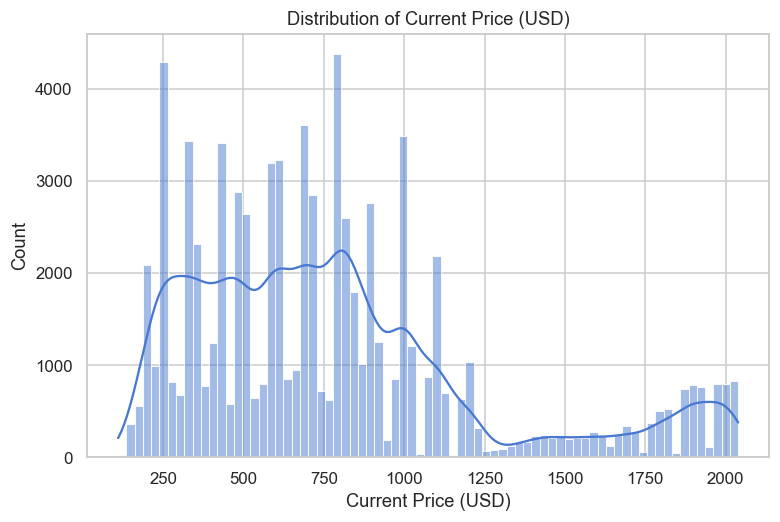

In [17]:
# Distribution of the target variable
plt.figure(figsize=(8,5))
sns.histplot(df['Current_Price_USD'], kde=True)
plt.title('Distribution of Current Price (USD)')
plt.xlabel('Current Price (USD)')
plt.show()

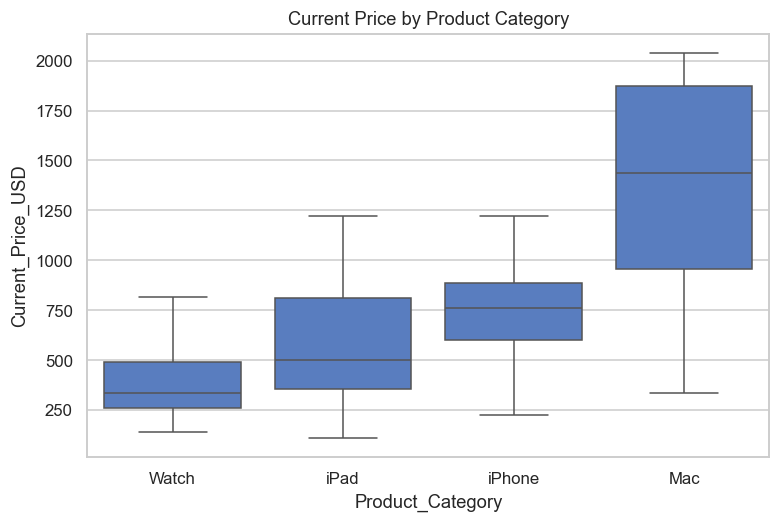

In [18]:
# Price by Product Category
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Product_Category', y='Current_Price_USD')
plt.title('Current Price by Product Category')
plt.show()

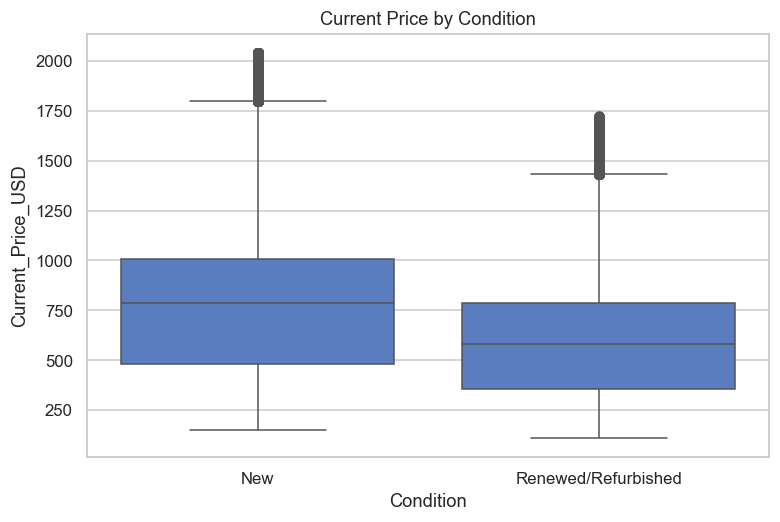

In [19]:
# Price by Condition
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Condition', y='Current_Price_USD')
plt.title('Current Price by Condition')
plt.show()

In [20]:
df_eda = df # making a copy to avoid changing the original file while showing the eda

In [21]:
# Feature Engineering: Convert Date to a Real Date Type
# Date is currently read as a string, not an actual date. 
# We need it converted to a proper datetime type before we can do any date math (like calculating how many days have passed since launch).
df_eda['Date'] = pd.to_datetime(df_eda['Date'])
print(df_eda['Date'].dtype)  # should now show datetime64, not object

datetime64[us]


Finding a Launch Date Proxy
This dataset doesn't include an official launch date for each product, so we build one ourselves: for each Model_Name, we take the earliest date a 'New' (not Refurbished) listing appears. We use only New listings for this because a refurbished unit logically can't appear before the product has actually launched and been used.
So New listings are the more reliable signal for when a product first became available.

In [22]:
launch_dates = (
    df[df['Condition'] == 'New']
    .groupby('Model_Name')['Date']
    .min()
    .reset_index()
    .rename(columns={'Date': 'Launch_Date_Proxy'})
)

launch_dates.head()

,Model_Name,Launch_Date_Proxy
0,Apple Watch Series 6 (44mm),2020-09-19
1,Apple Watch Series 7 (45mm),2021-10-15
2,Apple Watch Series 8 (45mm),2022-09-16
3,Apple Watch Series 9 (45mm),2023-09-22
4,Apple Watch Series X (45mm),2024-09-21


In [23]:
# Merge the Launch Date Proxy Back into the Main Data
# We attach the launch date proxy to every row based on which Model_Name it belongs to.
df_eda = df_eda.merge(launch_dates, on='Model_Name', how='left')
print(df_eda.columns.tolist())  # confirm exactly one Launch_Date_Proxy column

['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition', 'Launch_Price_USD', 'Current_Price_USD', 'Sale_Event', 'Stock_Status', 'Rating', 'Reviews_Count', 'days_since_launch', 'storage_gb', 'month', 'variant_tier', 'Launch_Date_Proxy']


In [24]:
# Feature Engineering: Calculate Days Since Launch
# Now that every row has its model's launch date attached, 
# we subtract that from the row's own listing date to get how many days had passed since that product launched.
df_eda['Days_Since_Launch'] = (df_eda['Date'] - df_eda['Launch_Date_Proxy']).dt.days
print(df_eda['Days_Since_Launch'].describe())

count    80000.000000
mean       685.485125
std        493.892944
min         -1.000000
25%        280.000000
50%        590.000000
75%       1005.000000
max       2141.000000
Name: Days_Since_Launch, dtype: float64


This scatter plot below is the direct visual test of H1: if price decreases with time since launch, we should see a downward trend as Days_Since_Launch increases. 
Color-coding by Condition also lets us see whether that trend differs between New and Refurbished listings.

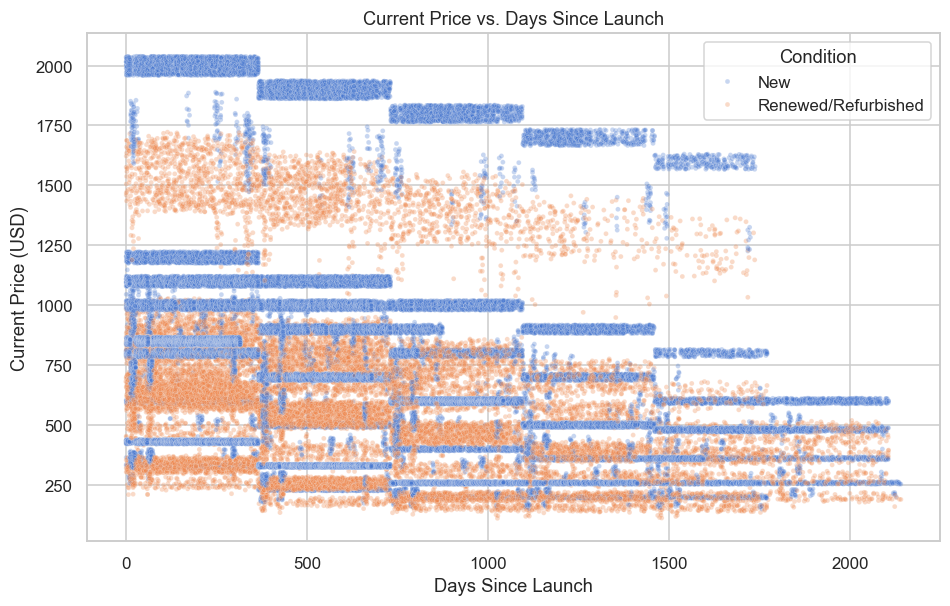

In [25]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_eda, x='Days_Since_Launch', y='Current_Price_USD', 
                 hue='Condition', alpha=0.3, s=10)
plt.title('Current Price vs. Days Since Launch')
plt.xlabel('Days Since Launch')
plt.ylabel('Current Price (USD)')
plt.show()

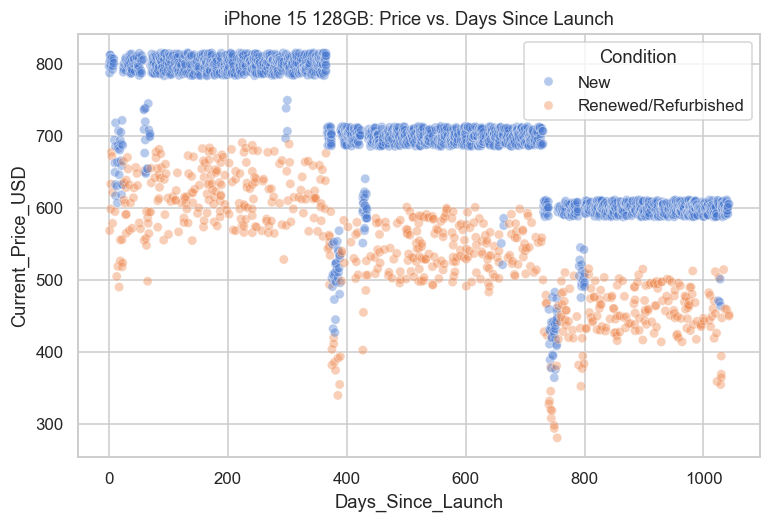

In [26]:
# Let's focus on a single model to see how its price changes over time since launch.
# At first glance this looks like gradual depreciation, but closer inspection reveals a flat-then-step down pattern rather than a smooth decline.
one_model = df_eda[df_eda['Model_Name'] == 'iPhone 15 128GB']

plt.figure(figsize=(8,5))
sns.scatterplot(data=one_model, x='Days_Since_Launch', y='Current_Price_USD', hue='Condition', alpha=0.4)
plt.title('iPhone 15 128GB: Price vs. Days Since Launch')
plt.show()

In [27]:
# Get this model's launch date proxy
launch_date = df_eda[df_eda['Model_Name'] == 'iPhone 15 128GB']['Launch_Date_Proxy'].iloc[0]
print("Launch date:", launch_date)

# When did iPhone 16 launch, per your data?
iphone16_launch = df_eda[df_eda['Model_Name'] == 'iPhone 16 128GB']['Launch_Date_Proxy'].iloc[0]
print("iPhone 16 launch date:", iphone16_launch)

Launch date: 2023-09-22 00:00:00
iPhone 16 launch date: 2024-09-20 00:00:00


In [28]:
# Get launch date + category for each model, sorted chronologically within category
model_launches = (
    df_eda[df_eda['Condition']=='New']
    .groupby(['Product_Category','Model_Name'])['Date']
    .min()
    .reset_index()
    .rename(columns={'Date':'Launch_Date'})
    .sort_values(['Product_Category','Launch_Date'])
)

# Days until the *next* model in the same category launches
model_launches['Next_Launch_Gap_Days'] = (
    model_launches.groupby('Product_Category')['Launch_Date']
    .shift(-1) - model_launches['Launch_Date']
).dt.days

print(model_launches)

   Product_Category                        Model_Name Launch_Date  \
0               Mac              MacBook Air M1 256GB  2020-11-17   
3               Mac  MacBook Pro 14-inch M1 Pro 512GB  2021-10-26   
1               Mac              MacBook Air M2 256GB  2022-07-15   
4               Mac  MacBook Pro 14-inch M2 Pro 512GB  2023-01-24   
5               Mac  MacBook Pro 14-inch M3 Pro 512GB  2023-11-07   
2               Mac              MacBook Air M3 256GB  2024-03-08   
6               Mac  MacBook Pro 14-inch M4 Pro 512GB  2024-11-08   
7             Watch       Apple Watch Series 6 (44mm)  2020-09-19   
8             Watch       Apple Watch Series 7 (45mm)  2021-10-15   
9             Watch       Apple Watch Series 8 (45mm)  2022-09-16   
12            Watch                 Apple Watch Ultra  2022-09-23   
10            Watch       Apple Watch Series 9 (45mm)  2023-09-22   
13            Watch               Apple Watch Ultra 2  2023-09-22   
11            Watch       Apple Wa

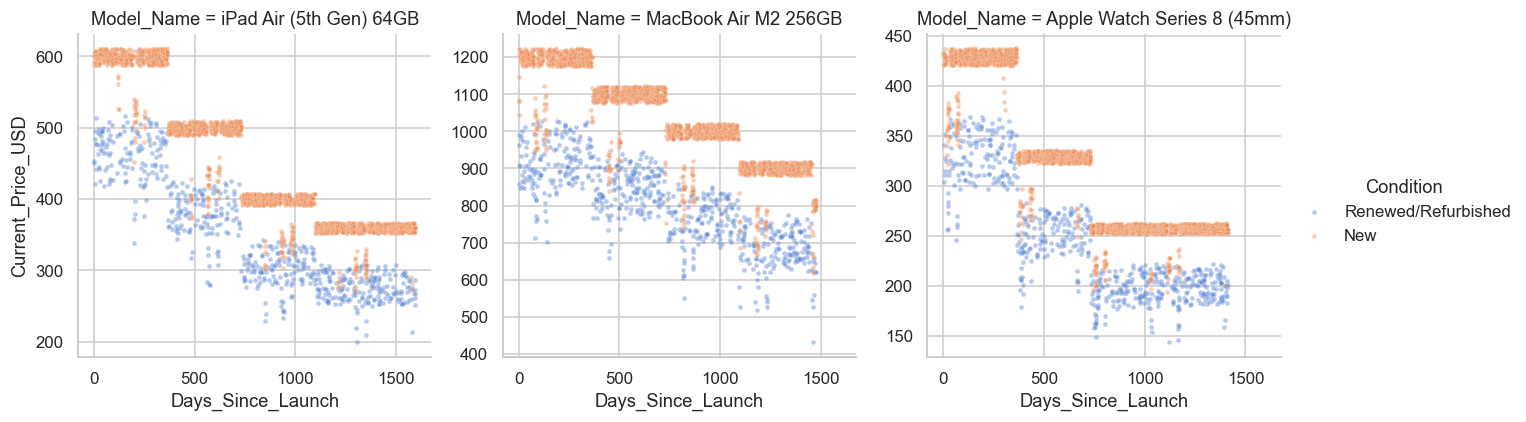

In [29]:
# Let's visualize the price trends for a few different models to see how they compare over time since launch.
# We see the same pattern of price depreciation over time for each model.
# The price drop seems to happen after a certain number of days, which may correspond to the launch of a new model or other market factors.
sample_models = ['MacBook Air M2 256GB', 'iPad Air (5th Gen) 64GB', 'Apple Watch Series 8 (45mm)']

sample_df = df_eda[df_eda['Model_Name'].isin(sample_models)]

g = sns.FacetGrid(sample_df, col='Model_Name', hue='Condition', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.scatterplot, x='Days_Since_Launch', y='Current_Price_USD', alpha=0.4, s=10)
g.add_legend()
plt.show()

The initial scatter plot of Current_Price_USD against Days_Since_Launch appears noisy at the aggregate level, particularly for Renewed/Refurbished listings, making any trend difficult to read directly.

Isolating individual models reveals a clearer structure: New-condition prices remain largely flat for extended periods, then drop sharply in discrete steps, rather than declining continuously. This pattern was consistent across four models spanning three product categories (iPhone, iPad, Watch, Mac).
These step points align closely with each product line's own successor's proxy launch date (i.e., the successor's earliest New listing date in this dataset — not an independently verified Apple release date) — for example, iPhone 15 → iPhone 16: 364 days; Apple Watch Series 8 → Series 9: 371 days. This alignment is suggestive of release-driven pricing behavior, though it should be read with the same proxy-date caveat noted earlier in this notebook, and is based on a small, manually-checked sample rather than a systematic check across all 31 models.

Sanity Check
A well-formed Days_Since_Launch should have a minimum at or near 0 (since New listings define day zero for each model) and no extreme or unexplainable values. 
One small negative value may appear due to a minor one-day data inconsistency identified during EDA and is treated as noise. 

In [30]:
df_eda[df_eda['Days_Since_Launch'] < 0]

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Current_Price_USD,Sale_Event,Stock_Status,Rating,Reviews_Count,days_since_launch,storage_gb,month,variant_tier,Launch_Date_Proxy,Days_Since_Launch
1409,2021-05-22,Amazon,iPad,iPad Pro 11-inch (M1) 128GB,Renewed/Refurbished,799,681.08,None,In Stock,4.0,84,0,128.0,5,Pro,2021-05-23,-1


In [31]:
# Treat as 0 days since launch.
df_eda.loc[df_eda['Days_Since_Launch'] < 0, 'Days_Since_Launch'] = 0

In [36]:
#Reviews_Count → correlation with price: -0.265
# This means there's a weak-to-moderate negative relationship: as review count goes up, 
# price tends to go down slightly, and vice versa. In the real world, this doesn't make intuitive sense
#this column likely doesn't represent real customer engagement — it looks like an artifact of how the synthetic dataset was generated. 
df_eda.groupby('Model_Name')['Reviews_Count'].apply(lambda x: x.is_monotonic_increasing)
print(df_eda[['Reviews_Count', 'Current_Price_USD']].corr())

                   Reviews_Count  Current_Price_USD
Reviews_Count           1.000000          -0.265293
Current_Price_USD      -0.265293           1.000000


In [37]:
# Rating → correlation with price: 0.1106, 0 missing values
# This is a very weak positive relationship
print(df_eda['Rating'].isnull().sum())
print(df_eda[['Rating', 'Current_Price_USD']].corr())

0
                     Rating  Current_Price_USD
Rating             1.000000           0.110571
Current_Price_USD  0.110571           1.000000


In [38]:
# Stock_Status → group means: In Stock $819.92, Low Stock $708.52, Out of Stock $694.37
# Keep this feature since it may have some predicting power i.e. high prices items move faster vs. low priced items going out of stock.
df_eda.groupby('Stock_Status')['Current_Price_USD'].mean()

Stock_Status
In Stock        819.919547
Low Stock       708.515858
Out of Stock    694.365889
Name: Current_Price_USD, dtype: float64

To Drop: Current_Price_INR, Launch_Price_INR, Discount_Pct (all leakage/redundancy), Reviews_Count (verified noise), Date, Model_Name, Launch_Date_Proxy (raw identifiers/dates, replaced by Days_Since_Launch)
To Keep as features: Launch_Price_USD, Days_Since_Launch, Rating, Product_Category (one-hot), Condition (one-hot), Platform (one-hot), Stock_Status (one-hot encoding)
